<a href="https://colab.research.google.com/github/NahuelCostaCortez/Remaining-Useful-Life-Estimation-Variational/blob/main/RULRVE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
########################################################################################
# BLSTM-VAE-R.ipynb
# 16-03-2026 - Jose Carlos Alves de Almeida
# This Jupyter Notebook implements the prediction models to support the analysis of prognostic performance 
# in a comprehensive manner to support the thesis project  Human-Machine Collaboration in Industry 5.0: Linking 
# prognostic Algorithms to Sustainable, Resilient, and Human-Centric Maintenance. 
#################################################################################################################

In [2]:
import warnings

import utils

# Ensure the LRFinder utility is imported here
from utils import LRFinder 
import ProgPerfMetrics as ppm
#import performanceMerics as pm
import numpy as np
import pandas as pd
import tensorflow as tf
#from tensorflow import keras
#import keras
from keras.layers import Input, Dense, LSTM, RepeatVector, Bidirectional, Masking, Concatenate, Reshape, Lambda, Conv1D, Dropout, MaxPooling1D, Flatten
from keras.utils import serialize_keras_object, deserialize_keras_object
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import random
import time
import seaborn as sns
import os

# Import the correct registration utility for older TensorFlow/Keras versions
from keras.utils import register_keras_serializable

# Save metrics_data to a text file
import pickle

# Publication-quality IEEE Figure Version
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
})

warnings.simplefilter('ignore')


# C-MAPSS Dataset

In [3]:
# Define dataset
dataset = "FD001" # "FD001", "FD002", "FD003", or "FD004"

# Define regressor type
regressor_type = "CNN"  # "ANN" or "CNN" or "LSTM"

# Define sensors to work with 
sensors = ['s_2','s_3', 's_4', 's_7', 's_8', 's_11', 's_12', 's_13', 's_15', 's_17', 's_20', 's_21'] # JC 2, 3, 4, 7, 8, 11, 12, 13, 15, 17, 20, and 21

# Set window length
sequence_length = 30

# Set smoothing intensity for sensor values (alpha for exponential moving average)
alpha = 0.1

# Set max RUL for RUL labels (threshold for RUL values)
threshold = 125 

# Load data
x_train, y_train, x_val, y_val, x_test, y_test = utils.get_data(dataset, sensors, sequence_length, alpha, threshold)

x_train.shape  # Check shape of x_train

(14241, 30, 12)

# BLSTM-VAE-R Model

In [4]:
# Setup the network parameters:
timesteps = x_train.shape[1]
input_dim = x_train.shape[2]
intermediate_dim = 300
batch_size = 128
latent_dim = 8 #8 - 5
epochs = 10

# Mask used to mask values in sequences with less than 30 cycles until 30 is reached
masking_value = -99.

In [5]:
## 🛠️ FIX: Custom Layer to Handle Masking (Option 1)
# Here is the complete fixed code, incorporating the recommended SequenceSelector custom layer to explicitly handle the mask 
# and resolve the UserWarning.
@register_keras_serializable(package="Custom", name="SequenceSelector")
class SequenceSelector(tf.keras.layers.Layer):
    """
    Custom layer to select a specific timestep from the sequence 
    (defaults to the last timestep) and explicitly drop the sequence mask.
    """
    def __init__(self, index=-1, **kwargs):
        super().__init__(**kwargs)
        self.index = index

    # You must also have get_config() if you have __init__ arguments
    def get_config(self):
        config = super().get_config()
        config.update({"index": self.index})
        return config

    def call(self, inputs):
        # Select the last timestep of the sequence (axis=1)
        if self.index == -1:
             # tf.shape(inputs)[1] gets the current number of timesteps
             return tf.gather(inputs, tf.shape(inputs)[1] - 1, axis=1)
        else:
             return tf.gather(inputs, self.index, axis=1)

    # 🌟 Implementation of compute_mask 🌟
    # This explicitly tells Keras that the output is NOT a sequence and 
    # should NOT have a mask attached. This silences the UserWarning.
    def compute_mask(self, inputs, mask=None):
        return None 
    
    def get_config(self):
        config = super().get_config()
        config.update({"index": self.index})
        return config

## You previously used SequenceSelector for one Lambda layer. You must convert the 
## remaining three Lambda layers that are part of your encoder's attention mechanism:
@register_keras_serializable(package="Custom", name="ExpandDimLayer")
class ExpandDimLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.expand_dims(inputs, 1)
    def get_config(self): return super().get_config()

@register_keras_serializable(package="Custom", name="SigmoidLayer")
class SigmoidLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.nn.sigmoid(inputs)
    def get_config(self): return super().get_config()

@register_keras_serializable(package="Custom", name="ReduceSumLayer")
class ReduceSumLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.reduce_sum(inputs, axis=1)
    def get_config(self): return super().get_config()

# Note: You don't need a custom layer for `tf.nn.softmax(x, axis=1)` 
# as Keras has a Softmax layer: keras.layers.Softmax(axis=1).

## 🛠️ AUXILIARY LAYER: Sampling (Required for VAE/RVE)
@register_keras_serializable(package="Custom", name="Sampling")
class Sampling(tf.keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a data point."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [6]:
## 🏗️ FIXED ENCODER MODEL DEFINITION
# ----------------------- New Encoder -----------------------
# Input layer
inputs = tf.keras.layers.Input(shape=(timesteps, input_dim,), name='encoder_input')
mask = tf.keras.layers.Masking(mask_value=masking_value)(inputs)

# LSTM encoding (propagates the mask)
x_encoded = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(intermediate_dim, return_sequences=True, return_state=False)
)(mask)

# 1. Attention Mechanism

# Replace the first Lambda layer with the custom SequenceSelector layer
query = SequenceSelector(name='sequence_selector')(x_encoded)

# The rest of the attention block can remain Lambda layers, 
# as the subsequent operations are element-wise or sequence-preserving,
# *but* the warning was specifically about the sequence-to-vector transition.

# The query must be reshaped back into a sequence of length 1 for broadcasting
# 1. Reshaping for broadcasting: USE CUSTOM LAYER
query_with_time_axis = ExpandDimLayer()(query)

logits = tf.keras.layers.Dense(1)(x_encoded) + tf.keras.layers.Dense(1)(query_with_time_axis)

# 2. Score activation: USE CUSTOM LAYER (or built-in Dense(..., activation='sigmoid'))
score = SigmoidLayer()(logits) 
# OR use built-in: score = tf.keras.layers.Dense(1, activation='sigmoid')(logits)

# 3. Softmax: USE BUILT-IN LAYER (Best practice)
attn_weights = tf.keras.layers.Softmax(axis=1)(score)

# 4. Context vector reduction: USE CUSTOM LAYER
context_vector = attn_weights * x_encoded
context_vector = ReduceSumLayer()(context_vector) # <--- Replaced final Lambda

# Map the context vector to the latent space parameters
mu = tf.keras.layers.Dense(latent_dim, name="z_mean")(context_vector)
sigma = tf.keras.layers.Dense(latent_dim, name="z_log_var")(context_vector)
z = Sampling()([mu, sigma])

encoder = tf.keras.Model(inputs, [mu, sigma, z], name='encoder')

# You can now save the model without the UserWarning
# encoder.save('fixed_encoder.keras')

print(encoder.summary())

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 30, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 30, 12)    │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 30, 12)    │          0 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 30)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 600)   │    751,200 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_selector   │ (None, 600)       │          0 │ bidirectional[0]… │
│ (SequenceSelector)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_dim_layer    │ (None, 1, 600)    │          0 │ sequence_selecto… │
│ (ExpandDimLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │        601 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1)      │        601 │ expand_dim_layer… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 1)     │          0 │ dense[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sigmoid_layer       │ (None, 30, 1)     │          0 │ add[0][0]         │
│ (SigmoidLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 30, 1)     │          0 │ sigmoid_layer[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 30, 600)   │          0 │ softmax[0][0],    │
│                     │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduce_sum_layer    │ (None, 600)       │          0 │ multiply[0][0]    │
│ (ReduceSumLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 8)         │      4,808 │ reduce_sum_layer… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 8)         │      4,808 │ reduce_sum_layer… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 8)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 762,018 (2.91 MB)

 Trainable params: 762,018 (2.91 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
# ----------------------- ANN Regressor --------------------
# Note: Changed this code in 19-11-2025. Changed activation function from 'tanh' to 'relu' and added Dropout layer.
reg_latent_inputs = Input(shape=(latent_dim,), name='z_sampling_reg')
reg_intermediate = Dense(200, activation='relu')(reg_latent_inputs) #tanh

# Regularization (Added for consistency)
reg_intermediate = Dropout(0.5, name='dropout_regularization')(reg_intermediate)
reg_outputs = Dense(1, name='reg_output')(reg_intermediate)

# Instantiate the regressor model:
ann_regressor = tf.keras.Model(reg_latent_inputs, reg_outputs, name='ann_regressor')
print(ann_regressor.summary())
# -------------------------------------------------------

Model: "ann_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling_reg (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │         1,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 200)            │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reg_output (Dense)              │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001 (7.82 KB)

 Trainable params: 2,001 (7.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
# ----------------------- CNN Regressor --------------------
reg_latent_inputs = Input(shape=(latent_dim,), name='z_sampling_reg')

# Reshape inputs layer to change shape to (batch_size, latent_dim, 1)
reg_latent_inputs = Reshape((latent_dim, 1))(reg_latent_inputs)


reg_inter_1 = Conv1D(filters=64, kernel_size=5, activation='relu', name="Conv1D_1")(reg_latent_inputs) #kernel_size=5 - 3
#reg_inter_1 = Dropout(0.5)(reg_inter_1)
reg_inter_2 = Conv1D(filters=32, kernel_size=3, activation='relu', name="Conv1D_2")(reg_inter_1) #kernel_size=3 - 2
#reg_inter_3 = Conv1D(filters=16, kernel_size=2, activation='relu', name="Conv1D_3")(reg_inter_2)
reg_inter_3 = MaxPooling1D(pool_size=2, name="MaxPooling1D")(reg_inter_2)
reg_inter_4 = Flatten()(reg_inter_3)
reg_inter_5 = Dense(32, activation='relu', name="Dense_1")(reg_inter_4)
reg_inter_5 = Dropout(0.5)(reg_inter_5)
reg_outputs = Dense(1, activation='relu', name="Dense_2")(reg_inter_5)

# Instantiate the regression model:
cnn_regressor = tf.keras.Model(reg_latent_inputs, reg_outputs, name='cnn_regressor')
print(cnn_regressor.summary())
# -------------------------------------------------------

Model: "cnn_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_19CLONE            │ (None, 8, 1)           │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_1 (Conv1D)               │ (None, 4, 64)          │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 2, 32)          │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPooling1D (MaxPooling1D)     │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,649 (29.88 KB)

 Trainable params: 7,649 (29.88 KB)

 Non-trainable params: 0 (0.00 B)

None


In [9]:
# ----------------------- LSTM Regressor --------------------
reg_latent_inputs = Input(shape=(latent_dim,), name='z_sampling_reg')

# Reshape inputs layer to change shape to (batch_size, latent_dim, 1)
reg_latent_inputs = Reshape((latent_dim, 1))(reg_latent_inputs)


reg_inter_1 = LSTM(50, activation='tanh', return_sequences=False, input_shape=(latent_dim, 1))(reg_latent_inputs) #kernel_size=5 - 3
#reg_inter_1 = Dropout(0.5)(reg_inter_1)
reg_inter_2 = Dense(32, activation='relu', name="Dense_1")(reg_inter_1) #kernel_size=3 - 2
#reg_inter_3 = Dense(32, activation='relu', name="Dense_1")(reg_inter_4)
reg_inter_2 = Dropout(0.5)(reg_inter_2)
reg_outputs = Dense(1, name="Dense_2")(reg_inter_2)

# Instantiate the regression model:
lstm_regressor = tf.keras.Model(reg_latent_inputs, reg_outputs, name='lstm_regressor')
print(lstm_regressor.summary())
# -------------------------------------------------------

Model: "lstm_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_27CLONE            │ (None, 8, 1)           │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 32)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,065 (47.13 KB)

 Trainable params: 12,065 (47.13 KB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# ----------------------- Decoder --------------------
'''
The decoder has not been used in this implementation, but it is defined here for completeness and potential future use.
'''
latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
h_decoded = RepeatVector(timesteps)(latent_inputs)
h_decoded = Bidirectional(LSTM(intermediate_dim, return_sequences=True))(h_decoded) 

# decoded layer
outputs = LSTM(input_dim, return_sequences=True)(h_decoded) 

# Instantiate the decoder model:
decoder = tf.keras.Model(latent_inputs, outputs, name='decoder')
print(decoder.summary())
# -------------------------------------------------------

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 30, 600)        │       741,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 12)         │        29,424 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,024 (2.94 MB)

 Trainable params: 771,024 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

None


In [11]:
# Define the regressor model to be used based on the selected regressor type
# Selected regressor
selected_regressor = None

if regressor_type == "ANN":
    selected_regressor = ann_regressor
elif regressor_type == "CNN":
    selected_regressor = cnn_regressor
elif regressor_type == "LSTM":
    selected_regressor = lstm_regressor
else:
    selected_regressor = None
    print("Error: Unknown regressor type selected.")

print(f"Selected Regressor: {regressor_type}")
print(f"Selected Dataset: {dataset}")


Selected Regressor: CNN
Selected Dataset: FD001


In [12]:
@register_keras_serializable(package="Custom", name="BVAE_R")
class BVAE_R(tf.keras.Model):
    def __init__(self, encoder, selected_regressor, decoder=None, **kwargs):
        super(BVAE_R, self).__init__(**kwargs)
        self.encoder = encoder
        self.regressor = selected_regressor
        self.decoder = decoder

        # Loss trackers are internal state and do not need to be saved/reloaded 
        # via config, as they are initialized in __init__
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        self.reg_loss_tracker = tf.keras.metrics.Mean(name="reg_loss")
        
        if self.decoder!=None:
          self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
          print("Decoder is not None")

    # By implementing both get_config() and from_config(), you make your custom RVE model fully serializable, 
    # resolving the NotImplementedError when calling rve.save().
    
    # This method serializes the Keras sub-objects.
    def get_config(self):
        # 1. Start with the base config
        config = super().get_config()
        
        # 2. Serialize and add inner Keras components to the config
        config.update({
            "encoder": serialize_keras_object(self.encoder),
            "selected_regressor": serialize_keras_object(self.regressor),
            # Handle decoder being None
            "decoder": serialize_keras_object(self.decoder) if self.decoder else None,
        })
        return config
    
    # This static method is crucial for loading the model.
    @classmethod
    # 🌟 THE FINAL FIX IS HERE: Include custom_objects argument 🌟
    def from_config(cls, config, custom_objects=None):
        # 1. Pop serialized configs for inner layers
        encoder_config = config.pop("encoder")
        selected_regressor_config = config.pop("selected_regressor")
        decoder_config = config.pop("decoder")
        
        # 2. Deserialize the Keras components using the utility function
        #    Note: custom_objects argument is passed internally by Keras
        #          but we ensure it's provided if needed for nested deserialization.
        encoder = deserialize_keras_object(encoder_config, custom_objects=custom_objects)
        selected_regressor = deserialize_keras_object(selected_regressor_config, custom_objects=custom_objects)
        
        decoder = (
            deserialize_keras_object(decoder_config, custom_objects=custom_objects) 
            if decoder_config is not None else None
        )

        # 3. Recreate the RVE instance
        return cls(
            encoder=encoder,
            selected_regressor=selected_regressor,
            decoder=decoder,
            **config  # Pass remaining kwargs (like name, dtype)
        )
    
    # ... inside the CustomDenseLayer class ... # 14/11/2025

    def get_build_config(self):
        """
        A helper method to generate configuration specifically
        related to the *built* state (e.g., input shape).
        """
        if not self.built:
            # The layer hasn't been called yet, so we don't know the input_shape.
            return {"built": False}

        # Keras often stores the 'input_spec' after build is called
        return {
            "built": True,
            # We can't always guarantee a single input_shape, but for a simple
            # layer, we can extract the input dimension.
            #"input_dim": self.encoder.shape[0] if self.encoder is not None else None
            #"input_dim": self.encoder.input_shape.as_list() if self.encoder is not None else None
            "input_dim": self.input_shape.as_list() if hasattr(self, 'input_shape') else None
        }
    
    def build_from_config(self, config):
        """
        Creates the variables/state of the model using the configuration
        saved during the build phase.

        :param config: The build configuration dictionary saved via
                       get_build_config().
        """
        # The 'config' parameter here holds the dictionary previously returned
        # by self.get_build_config().
        
        # Example of creating state based on config:
        if config.get("built") and "input_shape" in config:
            input_shape = config["input_shape"]
            print(f"Re-building model state with input_shape: {input_shape}")
            # You must manually call the build method to create the weights
            self.build(input_shape)
        
        # NOTE: You must also ensure you have a get_build_config method 
        # that saves the necessary shape information for build().

        self.built = True # Set built to True to prevent subsequent build calls
         
    @property
    def metrics(self):
      if self.decoder!=None:
        return [
            self.total_loss_tracker,
            self.kl_loss_tracker,
            self.reg_loss_tracker,
            self.reconstruction_loss_tracker
        ]
      else:
        return [
            self.total_loss_tracker,
            self.kl_loss_tracker,
            self.reg_loss_tracker,
        ]

    def train_step(self, data):
        x, target_x = data
        with tf.GradientTape() as tape:
            # kl loss
            mu, sigma, z = self.encoder(x)
            kl_loss = -0.5 * (1 + sigma - tf.square(mu) - tf.exp(sigma))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            # Regressor
            reg_prediction = self.regressor(z)
            reg_loss = tf.reduce_mean(
                tf.keras.losses.mse(target_x, reg_prediction)
            )
            # Reconstruction
            if self.decoder!=None:
              reconstruction = self.decoder(z)
              reconstruction_loss = tf.reduce_mean(
                  tf.keras.losses.mse(x, reconstruction)
              )
              total_loss = kl_loss + reg_loss + reconstruction_loss
              self.reconstruction_loss_tracker.update_state(reconstruction_loss)
            else:
              total_loss = kl_loss + reg_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.reg_loss_tracker.update_state(reg_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "reg_loss": self.reg_loss_tracker.result(),
            #"rec_loss": self.reconstruction_loss_tracker.result()
        }


    def test_step(self, data):
        x, target_x = data

        # kl loss
        mu, sigma, z = self.encoder(x)
        kl_loss = -0.5 * (1 + sigma - tf.square(mu) - tf.exp(sigma))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        # Regressor
        reg_prediction = self.regressor(z)
        reg_loss = tf.reduce_mean(
            tf.keras.losses.mse(target_x, reg_prediction)
        )
        # Reconstruction
        if self.decoder!=None:
          reconstruction = self.decoder(z)
          reconstruction_loss = tf.reduce_mean(
              tf.keras.losses.mse(x, reconstruction)
          )

          total_loss = kl_loss + reg_loss + reconstruction_loss
        else:
          total_loss = kl_loss + reg_loss

        return {
            "loss": total_loss,
            "kl_loss": kl_loss,
            "reg_loss": reg_loss,
            #"rec_loss": reconstruction_loss
        }

Starting Learning Rate Finder...

Loss exploded. Stopping search.
Finder complete. Total steps: 542


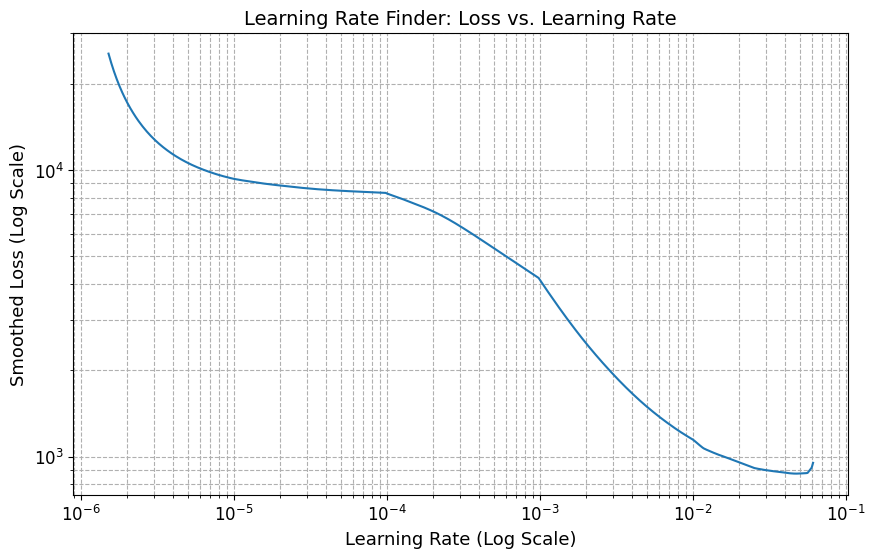


💡 Suggested optimal LR (Based on steepest slope): 1.51e-06
   Consider a range around 1.51e-06 to 4.67e-02
Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 67ms/step - kl_loss: 441.8862 - loss: 2728.7957 - reg_loss: 2286.9094 - val_kl_loss: 31.9847 - val_loss: 449.8781 - val_reg_loss: 417.8934
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - kl_loss: 102.8878 - loss: 657.9510 - reg_loss: 555.0632 - val_kl_loss: 12.8365 - val_loss: 134.8601 - val_reg_loss: 122.0236
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - kl_loss: 45.9048 - loss: 379.4965 - reg_loss: 333.5916 - val_kl_loss: 9.0903 - val_loss: 38.5278 - val_reg_loss: 29.4376
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - kl_loss: 31.1234 - loss: 268.9684 - reg_loss: 237.8449 - val_kl_loss: 8.0660 - val_loss: 18.5468 - val_reg_loss: 10.4808
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - kl_loss: 25.9292 - loss: 236.9654 - reg_loss: 211.0362 - val_kl_loss: 9.4453 - val_loss: 89.3181 - val_reg_loss: 79.8728
E

In [13]:
BVAE_R_model = BVAE_R(encoder, selected_regressor)

# Instantiate and Run lr Finder
# Temporarily disabled. You can re-enable it when you want to find the optimal learning rate.
utils.start_lr_finder(BVAE_R_model, x_train, y_train, batch_size=batch_size)

# TRAIN MODEL!!!
# After finding the optimal learning rate, you would typically compile and train the model as follows:
BVAE_R_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))#0.001

# 1. Define the input shape (exclude the batch dimension)
input_shape = x_train.shape[1:] 

# 2. Build the model explicitly
BVAE_R_model.build(input_shape=(None,) + input_shape) # (None,) is for the dynamic batch size

# 3. Model training
BVAE_R_model.fit(x_train, y_train, epochs=epochs, validation_data=(x_val, y_val), batch_size=batch_size)

#########################################################################################
# Save the trained model
model_path = './models/' + dataset + '_BVAE_R_' + regressor_type + '.keras'

#########################################################################################
# Save trined model (temporarily disabled to avoid saving issues)
########BVAE_R_model.save(model_path)    # temporarily disabled to avoid saving issues

# # To load it back 
# loaded_model = tf.keras.models.load_model('saved_model/my_model')
# return encoder, regressor
#return saved_VRAE_model.layers[1], saved_VRAE_model.layers[2]

In [14]:
#############################################################################################
# Obtain the latent variable representations for the given data using the encoder. 
#############################################################################################
def get_latent_variable(encoder, data):
    z, _, _  = encoder.predict(data)
    
    return z
# Generate predictions from input data
def generate_predictions(model, data):
    z = get_latent_variable(model.encoder, data)
    # Generate predictions using the model
    predictions = model.regressor.predict(z)
    return predictions

In [ ]:
#######################################################################################################################
# Load the stored models and obtain the latent variable representations and predicted RUL values for the test dataset.

# Evaluation flag
evaluation_mode = True

if evaluation_mode:
    # Define regressor type used during evaluation
    regressor_type = 'CNN'  # 'ANN', 'CNN', 'LSTM'

    # Define dataset
    dataset = 'FD001'  # 'FD001', 'FD002', 'FD003'

    # Load the trained RVE model
    model_path = './models/' + dataset + '_BVAE_R_' + regressor_type + '.keras'
    BVAE_R_model = tf.keras.models.load_model(model_path, custom_objects={"BVAE_R": BVAE_R})

    #BVAE_R_mdl, y_hat_test, test_z, train_z, val_z = load_RVE_model(dataset, regressor_type)
    if BVAE_R_model is not None:
        print('Model loaded successfully.')
     

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


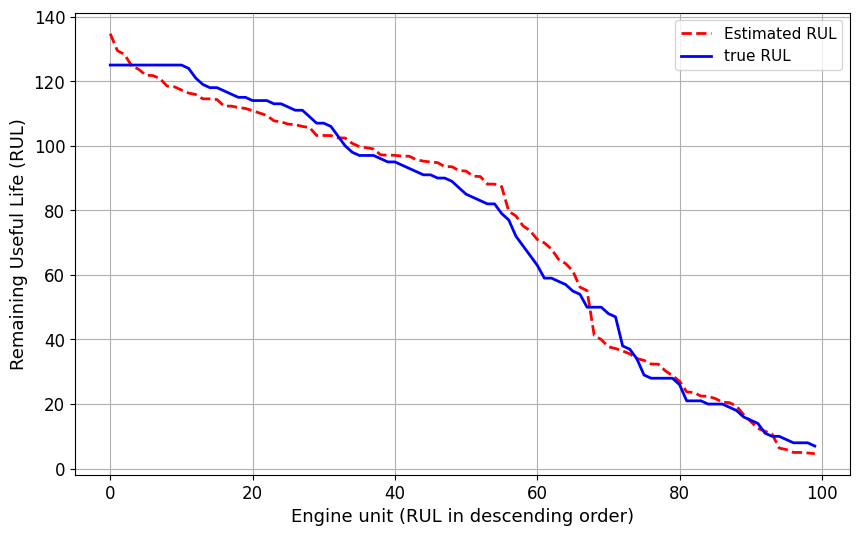

In [15]:
##############################################################################
# Plot True and predicted RUL for the test dataset
#########################################################################################

# Predicted RULs for test dataset - array
pred_RUL = generate_predictions(BVAE_R_model, x_test)
x = range(0, len(pred_RUL))
pred_RUL_data = pred_RUL.flatten().tolist() # Predicted RULs for test dataset - list !!!!!!!!!
pred_RUL = np.array(pred_RUL_data) # Predicted RULs for test dataset - array !!!!!!!!!!!

# true RUL values for test dataset - array
true_RUL = y_test.copy()  # Ground truth RULs for test dataset - array
true_RUL = np.clip(true_RUL, 0, threshold) # Clip true RUL values at the threshold=125
true_RUL_data = np.array(true_RUL).flatten().tolist() # Ground truth RULs for test dataset - array

# Sort both lists in descending order for better visualization
pred_RUL_data.sort(reverse=True)
true_RUL_data.sort(reverse=True)

# Save true and predicted RUL values to a text file for further analysis
ppm.save_RUL_to_file(true_RUL_data, pred_RUL_data, dataset, regressor_type)


# Create a figure
fig = plt.figure(figsize=(10, 6))

# Create a line plot
plt.plot(x, pred_RUL_data, color='red', linestyle='--', markersize=3, linewidth=2, label='Estimated RUL')
#plt.scatter(x, pred_RUL_data, color='red', marker='.', label='Estimated RUL')
plt.plot(x, true_RUL_data, color='blue', linestyle='-', markersize=3, linewidth=2, label='true RUL')# marker='o',

# Add labels and title
plt.xlabel('Engine unit (RUL in descending order)')
plt.ylabel('Remaining Useful Life (RUL)')

# Enable grid
plt.grid(True)
# Add a legend
plt.legend()

# Show the plot
plt.show()

#plt.savefig('./images/FD001_RUL'+'.jpg')

Regressor Type:  CNN
Aggregate RMSE: 14.078
PHM'08 mean score: 3.2315, PHM'08 per-sample scores length: 100
PHM'08 score for : 323.1546
Calculated RMSE: 14.0777
Calculated S_score: 323.1546


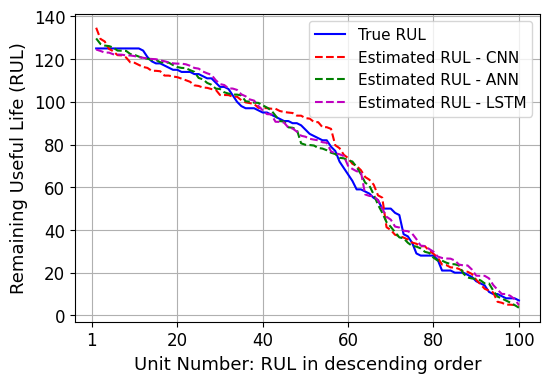

<Figure size 640x480 with 0 Axes>

In [16]:
#########################################################################################
# Summarize the prognostics performance metrics - RUL prediction, PH, alpha-lambda
# Attention!!!!!
# To run this code, ensure you have the true and predicted RUL data saved in text files as done above, 
# for all regressor models: CNN, ANN, LSTM.
###################################################################################################

# Aggregate RMSE
print("Regressor Type: ", regressor_type)
rmse_val = ppm.compute_rmse(true_RUL, pred_RUL)
print(f"Aggregate RMSE: {rmse_val:.3f}")

# Original PHM'08 scoring (mean and per-sample)
phm08_mean, phm08_per_sample = ppm.phm08_score(true_RUL, pred_RUL)
print(f"PHM'08 mean score: {phm08_mean:.4f}, PHM'08 per-sample scores length: {len(phm08_per_sample)}")
print(f"PHM'08 score for : {np.sum(phm08_per_sample):.4f}")

# This is the main function to calculate all metrics and save them to a dictionary for potential further analysis or plotting.
# Calculate all metrics and save to a dictionary for potential further analysis or plotting
rmse, sf = ppm.calculate_save_all_metrics(true_RUL,pred_RUL, regressor_type, dataset=dataset)
print(f"Calculated RMSE: {rmse:.4f}")
print(f"Calculated S_score: {sf:.4f}")

# Load actual and predicted RUL text files for all regressor models (CNN, ANN, LSTM) and store them 
# in a dictionary for consolidated plotting and analysis.
RUL_data_dict = ppm.load_actual_pred_RUL_from_files(dataset)

# 2. Plot consolidated RUL predictions for CNN and ANN
y_true = np.array(RUL_data_dict['y_true_CNN'])
y_pred = np.array(RUL_data_dict['y_pred_CNN'])
ppm.plot_rul_prediction(y_true, y_pred, rul_data=RUL_data_dict, dataset=dataset)



Plotting CNN Default Score Metrics - 2 ...


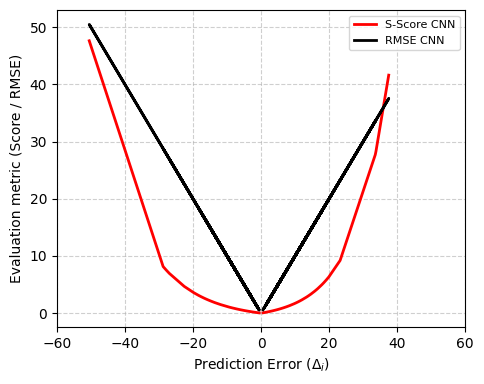


--- CNN S-score CM error metrics ---
CNN TP predictions: 26.00
CNN FP predictions : 20.00
CNN FN Predictions : 31.00
CNN TN Predictions : 23.00
CNN TPR : 0.46
CNN FPR : 0.47


<Figure size 640x480 with 0 Axes>

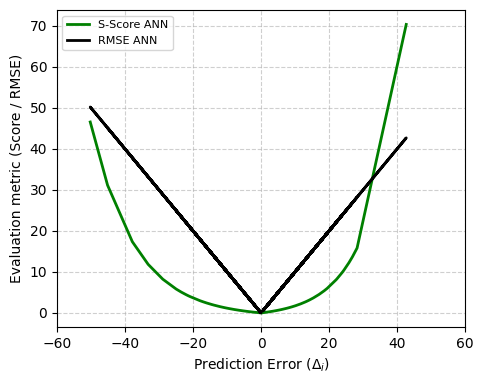


--- ANN S-score CM error metrics ---
ANN TP predictions: 30.00
ANN FP predictions : 16.00
ANN FN Predictions : 32.00
ANN TN Predictions : 22.00
ANN TPR : 0.48
ANN FPR : 0.42


<Figure size 640x480 with 0 Axes>

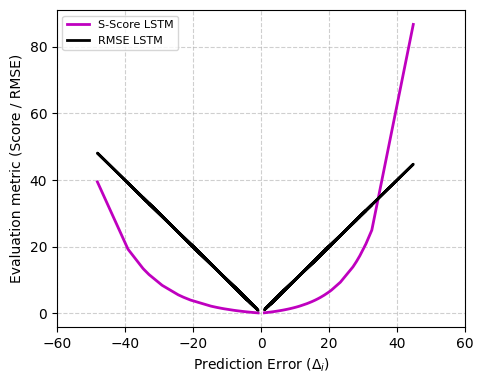


--- LSTM S-score CM error metrics ---
LSTM TP predictions: 31.00
LSTM FP predictions : 14.00
LSTM FN Predictions : 29.00
LSTM TN Predictions : 26.00
LSTM TPR : 0.52
LSTM FPR : 0.35
---------------------------------------


<Figure size 640x480 with 0 Axes>

In [19]:

# Plot Score Function metrics
model_type = regressor_type  # Options: 'CNN', 'ANN', 'LSTM'

metrics_dict_CNN, metrics_dict_ANN, metrics_dict_LSTM = ppm.load_metrics_data(dataset=dataset)

ppm.plotDefaultScoreMetrics('CNN', dict_CNN=metrics_dict_CNN, dict_ANN=metrics_dict_ANN, dict_LSTM=metrics_dict_LSTM, dataset=dataset)
ppm.plotDefaultScoreMetrics('ANN', dict_CNN=metrics_dict_CNN, dict_ANN=metrics_dict_ANN, dict_LSTM=metrics_dict_LSTM, dataset=dataset)
ppm.plotDefaultScoreMetrics('LSTM', dict_CNN=metrics_dict_CNN, dict_ANN=metrics_dict_ANN, dict_LSTM=metrics_dict_LSTM, dataset=dataset)



